In [ ]:
# from __future__ import annotations

# import os
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation

# # =========================
# # CONFIG (EDIT IF NEEDED)
# # =========================

# # 1) Put your csv path here (recommended), OR keep a few candidates.
# CSV_CANDIDATES = [
#     "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/processed_eit/1-8.csv",
# ]

# # 2) Output folder (your requested path)
# OUT_DIR = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/eit")
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# OUTPUT_MP4 = OUT_DIR / "eit1-8_realtime.mp4"
# OUTPUT_GIF = OUT_DIR / "eit1-8_realtime.gif"

# # Playback
# FPS = 60  # video frames per second

# # Scrolling window (choose ONE)
# WINDOW_SECONDS = 10.0     # show last N seconds
# # WINDOW_SAMPLES = 300    # alternatively: last N samples (comment WINDOW_SECONDS if using this)

# # Plot appearance
# FIGSIZE = (12, 6)
# LINE_WIDTH = 1.5
# ALPHA = 0.95

# CHANNELS = [f"eit_ch{i}" for i in range(1, 9)]
# TIMESTAMP_COL = "timestamp"

# # =========================
# # LOAD DATA
# # =========================
# def find_csv_path() -> str:
#     for p in CSV_CANDIDATES:
#         if os.path.exists(p):
#             return p
#     raise FileNotFoundError(
#         f"Could not find CSV. Tried: {CSV_CANDIDATES}\n"
#         f"Update CSV_CANDIDATES with your real macOS path."
#     )

# csv_path = find_csv_path()
# df = pd.read_csv(csv_path)

# if TIMESTAMP_COL not in df.columns:
#     raise ValueError(f"Missing '{TIMESTAMP_COL}' column in CSV.")

# missing = [c for c in CHANNELS if c not in df.columns]
# if missing:
#     raise ValueError(f"Missing channels in CSV: {missing}\nAvailable: {list(df.columns)}")

# # Parse timestamps like: '2026-01-29 18:31:29.487608'
# ts = pd.to_datetime(df[TIMESTAMP_COL], errors="coerce")
# if ts.isna().any():
#     bad = df.loc[ts.isna(), TIMESTAMP_COL].head(5).tolist()
#     raise ValueError(f"Some timestamps could not be parsed. Examples: {bad}")

# # Sort by time (in case)
# order = np.argsort(ts.values)
# df = df.iloc[order].reset_index(drop=True)
# ts = ts.iloc[order].reset_index(drop=True)

# # Relative time in seconds
# t0 = ts.iloc[0]
# t = (ts - t0).dt.total_seconds().to_numpy()

# # Force monotonic non-decreasing (handles tiny negatives / weird rows)
# t = np.maximum.accumulate(t)

# # Signal matrix: shape (N, C)
# Y = df[CHANNELS].to_numpy(dtype=float)
# N, C = Y.shape

# true_seconds = float(t[-1] - t[0]) if N > 1 else 0.0
# print(f"[INFO] Loaded: {csv_path}")
# print(f"[INFO] Samples: {N}, Channels: {C}")
# print(f"[INFO] True duration: {true_seconds:.3f} s")
# print(f"[INFO] Output folder: {OUT_DIR}")

# # =========================
# # BUILD FRAME-TO-SAMPLE MAP (time-accurate)
# # =========================
# # Each video frame represents a fixed time step (1/FPS). For that time, we pick the latest sample <= that time.
# if N <= 1 or true_seconds <= 1e-12:
#     video_times = np.arange(0.0, 1.0, 1.0 / FPS)
# else:
#     video_times = np.arange(0.0, t[-1] + 1e-12, 1.0 / FPS)

# sample_idx_per_frame = np.searchsorted(t, video_times, side="right") - 1
# sample_idx_per_frame = np.clip(sample_idx_per_frame, 0, N - 1)

# approx_video_seconds = len(sample_idx_per_frame) / FPS
# print(f"[INFO] Video frames: {len(sample_idx_per_frame)}")
# print(f"[INFO] Video duration: {approx_video_seconds:.3f} s @ {FPS} fps")

# # =========================
# # SETUP PLOT
# # =========================
# plt.rcParams.update({"font.size": 12})
# fig, ax = plt.subplots(figsize=FIGSIZE)

# lines = []
# for ch in CHANNELS:
#     (ln,) = ax.plot([], [], lw=LINE_WIDTH, alpha=ALPHA, label=ch)
#     lines.append(ln)

# ax.set_title("EIT channels (scrolling, real-time)")
# ax.set_xlabel("Time (s) from start")
# ax.set_ylabel("Value")
# ax.legend(loc="upper right", ncol=2, fontsize=9)
# ax.grid(True, alpha=0.25)

# # Stable y-limits from entire file
# ymin = np.nanmin(Y)
# ymax = np.nanmax(Y)
# pad = 0.03 * (ymax - ymin if ymax > ymin else 1.0)
# ax.set_ylim(ymin - pad, ymax + pad)

# # =========================
# # WINDOW HELPER
# # =========================
# use_window_seconds = True
# WINDOW_SAMPLES = None

# if "WINDOW_SECONDS" in globals() and WINDOW_SECONDS is not None:
#     use_window_seconds = True
# else:
#     use_window_seconds = False
#     if "WINDOW_SAMPLES" not in globals() or WINDOW_SAMPLES is None:
#         WINDOW_SAMPLES = 300

# def get_window_slice(sample_i: int):
#     i1 = sample_i + 1
#     if use_window_seconds:
#         left_time = t[sample_i] - float(WINDOW_SECONDS)
#         i0 = int(np.searchsorted(t, left_time, side="left"))
#         return i0, i1
#     else:
#         i0 = max(0, i1 - int(WINDOW_SAMPLES))
#         return i0, i1

# # =========================
# # ANIMATION UPDATE
# # =========================
# def init():
#     for ln in lines:
#         ln.set_data([], [])
#     if use_window_seconds:
#         ax.set_xlim(0, max(1e-6, min(float(WINDOW_SECONDS), float(t[-1]) if N > 1 else 1.0)))
#     else:
#         ax.set_xlim(0, 1e-6)
#     return lines

# def update(frame_idx: int):
#     sample_i = int(sample_idx_per_frame[frame_idx])
#     i0, i1 = get_window_slice(sample_i)

#     x = t[i0:i1]
#     yseg = Y[i0:i1, :]  # (len, C)

#     for k, ln in enumerate(lines):
#         ln.set_data(x, yseg[:, k])

#     if use_window_seconds:
#         right = float(t[sample_i])
#         left = max(0.0, right - float(WINDOW_SECONDS))
#         if right - left < 1e-6:
#             right = left + 1e-6
#         ax.set_xlim(left, right)
#     else:
#         ax.set_xlim(float(t[i0]), float(t[sample_i]) + 1e-6)

#     return lines

# anim = FuncAnimation(
#     fig,
#     update,
#     frames=len(sample_idx_per_frame),
#     init_func=init,
#     interval=1000.0 / FPS,
#     blit=True,
# )

# # =========================
# # SAVE VIDEO
# # =========================
# from matplotlib.animation import FFMpegWriter, PillowWriter, writers

# def save_mp4_or_gif():
#     # MP4 only if ffmpeg is available
#     if writers.is_available("ffmpeg"):
#         try:
#             print(f"[INFO] Saving MP4: {OUTPUT_MP4}")
#             writer = FFMpegWriter(
#                 fps=FPS,
#                 codec="libx264",
#                 extra_args=["-pix_fmt", "yuv420p"],  # safe for ffmpeg only
#             )
#             anim.save(str(OUTPUT_MP4), writer=writer, dpi=150)
#             print("[DONE] MP4 saved.")
#             return
#         except Exception as e:
#             print(f"[WARN] MP4 export failed. Reason:\n  {e}")
#     else:
#         print("[WARN] ffmpeg not found, skipping MP4.")
#         print("       Install via Homebrew:  brew install ffmpeg")
#         print("       Or via conda:         conda install -c conda-forge ffmpeg")

#     # Fallback GIF
#     try:
#         print(f"[INFO] Saving GIF: {OUTPUT_GIF}")
#         writer = PillowWriter(fps=FPS)
#         anim.save(str(OUTPUT_GIF), writer=writer, dpi=120)
#         print("[DONE] GIF saved.")
#     except Exception as e2:
#         raise RuntimeError(
#             "GIF export failed. Install pillow:\n"
#             "  pip install pillow\n"
#             f"GIF error: {e2}"
#         )

# save_mp4_or_gif()
# plt.close(fig)
# print("[DONE] All finished.")


[INFO] Loaded: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/processed_eit/1-8.csv
[INFO] Samples: 650, Channels: 8
[INFO] True duration: 47.140 s
[INFO] Output folder: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/eit
[INFO] Video frames: 2829
[INFO] Video duration: 47.150 s @ 60 fps
[INFO] Saving MP4: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/eit/eit1-8_realtime.mp4
[DONE] MP4 saved.
[DONE] All finished.


In [6]:
from IPython import get_ipython
import os
import time

_NOTIFY_EVERY_SECONDS = 2  # 防止太频繁，可改成 0

_last_notify_time = 0

def notify_cell_done(result):
    global _last_notify_time

    now = time.time()
    if now - _last_notify_time < _NOTIFY_EVERY_SECONDS:
        return
    _last_notify_time = now

    if result.error_in_exec is not None:
        os.system(
            """osascript -e 'display notification "Cell failed ❌" with title "VS Code Notebook"'"""
        )
        # os.system('say "cell failed"')
    else:
        os.system(
            """osascript -e 'display notification "Cell finished ✅" with title "VS Code Notebook"'"""
        )
        # os.system('say "done"')

ip = get_ipython()

# 避免重复注册
try:
    ip.events.unregister("post_run_cell", notify_cell_done)
except Exception:
    pass

ip.events.register("post_run_cell", notify_cell_done)

print("✅ Auto notification enabled for every notebook cell.")

✅ Auto notification enabled for every notebook cell.


# Modalities one by one

## EIT

In [1]:
from __future__ import annotations

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter, writers

# =========================
# CONFIG
# =========================
CSV_CANDIDATES = [
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/processed_eit/1-8.csv",
]

OUT_DIR = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/eit")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FPS = 60
WINDOW_SECONDS = 10.0  # scroll window length

FIGSIZE = (12, 6)
LINE_WIDTH = 1.5
ALPHA = 0.95

TIMESTAMP_COL = "timestamp"

GROUPS = [
    ([f"eit_ch{i}" for i in range(1, 5)], "EIT upperarm channels", "eit1-8_upperarm_realtime"),
    ([f"eit_ch{i}" for i in range(5, 9)], "EIT forearm channels", "eit1-8_forearm_realtime"),
]

BACKGROUND_BLUE = "#EAF4FF"   # 你可以换成任何喜欢的蓝色

# =========================
# LOAD DATA
# =========================
def find_csv_path() -> str:
    for p in CSV_CANDIDATES:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find CSV. Tried: {CSV_CANDIDATES}")

csv_path = find_csv_path()
df = pd.read_csv(csv_path)

if TIMESTAMP_COL not in df.columns:
    raise ValueError(f"Missing '{TIMESTAMP_COL}' column in CSV.")

ts = pd.to_datetime(df[TIMESTAMP_COL], errors="coerce")
if ts.isna().any():
    bad = df.loc[ts.isna(), TIMESTAMP_COL].head(5).tolist()
    raise ValueError(f"Some timestamps could not be parsed. Examples: {bad}")

# Sort by time
order = np.argsort(ts.values)
df = df.iloc[order].reset_index(drop=True)
ts = ts.iloc[order].reset_index(drop=True)

t0 = ts.iloc[0]
t = (ts - t0).dt.total_seconds().to_numpy()
t = np.maximum.accumulate(t)  # force monotonic non-decreasing

N = len(t)
true_seconds = float(t[-1] - t[0]) if N > 1 else 0.0

print(f"[INFO] Loaded: {csv_path}")
print(f"[INFO] Samples: {N}")
print(f"[INFO] True duration: {true_seconds:.3f} s")
print(f"[INFO] Output folder: {OUT_DIR}")

# =========================
# FRAME -> SAMPLE MAP (time-accurate)
# =========================
if N <= 1 or true_seconds <= 1e-12:
    video_times = np.arange(0.0, 1.0, 1.0 / FPS)
else:
    video_times = np.arange(0.0, t[-1] + 1e-12, 1.0 / FPS)

sample_idx_per_frame = np.searchsorted(t, video_times, side="right") - 1
sample_idx_per_frame = np.clip(sample_idx_per_frame, 0, N - 1)

print(f"[INFO] Video frames: {len(sample_idx_per_frame)}")
print(f"[INFO] Video duration: {len(sample_idx_per_frame)/FPS:.3f} s @ {FPS} fps")

# =========================
# SAVE HELPERS
# =========================
def save_animation(anim, base_name: str, dpi_mp4=150, dpi_gif=120):
    mp4_path = OUT_DIR / f"{base_name}.mp4"
    gif_path = OUT_DIR / f"{base_name}.gif"

    if writers.is_available("ffmpeg"):
        try:
            print(f"[INFO] Saving MP4: {mp4_path}")
            writer = FFMpegWriter(
                fps=FPS,
                codec="libx264",
                extra_args=["-pix_fmt", "yuv420p"],
            )
            anim.save(str(mp4_path), writer=writer, dpi=dpi_mp4)
            print("[DONE] MP4 saved.")
            return
        except Exception as e:
            print(f"[WARN] MP4 export failed. Reason:\n  {e}")
    else:
        print("[WARN] ffmpeg not found, skipping MP4.")
        print("       Install via Homebrew:  brew install ffmpeg")
        print("       Or via conda:         conda install -c conda-forge ffmpeg")

    # Fallback GIF
    print(f"[INFO] Saving GIF: {gif_path}")
    writer = PillowWriter(fps=FPS)
    anim.save(str(gif_path), writer=writer, dpi=dpi_gif)
    print("[DONE] GIF saved.")

# =========================
# BUILD + SAVE ONE GROUP
# =========================
def make_group_video(channels: list[str], title: str, base_name: str):
    missing = [c for c in channels if c not in df.columns]
    if missing:
        raise ValueError(f"Missing channels in CSV: {missing}\nAvailable: {list(df.columns)}")

    Y = df[channels].to_numpy(dtype=float)  # (N, C)
    C = Y.shape[1]

    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=FIGSIZE)

    # 固定背景颜色：不再根据 label 改变背景
    fig.patch.set_facecolor("white")
    ax.set_facecolor(BACKGROUND_BLUE)

    lines = []
    for ch in channels:
        (ln,) = ax.plot([], [], lw=LINE_WIDTH, alpha=ALPHA, label=ch)
        lines.append(ln)

    ax.set_title(f"{title} (scrolling, real-time)")
    ax.set_xlabel("Time (s) from start")
    ax.set_ylabel("Value")

    # 只保留 channel legend
    ax.legend(loc="upper right", ncol=2, fontsize=9, framealpha=0.9)

    ax.grid(True, alpha=0.25)

    # y-limits per group
    ymin = np.nanmin(Y)
    ymax = np.nanmax(Y)
    pad = 0.03 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - pad, ymax + pad)

    def get_window_slice(sample_i: int):
        i1 = sample_i + 1
        left_time = t[sample_i] - float(WINDOW_SECONDS)
        i0 = int(np.searchsorted(t, left_time, side="left"))
        return i0, i1

    def init():
        for ln in lines:
            ln.set_data([], [])

        ax.set_xlim(
            0,
            max(
                1e-6,
                min(float(WINDOW_SECONDS), float(t[-1]) if N > 1 else 1.0),
            ),
        )

        return lines

    def update(frame_idx: int):
        sample_i = int(sample_idx_per_frame[frame_idx])
        i0, i1 = get_window_slice(sample_i)

        x = t[i0:i1]
        yseg = Y[i0:i1, :]

        for k, ln in enumerate(lines):
            ln.set_data(x, yseg[:, k])

        right = float(t[sample_i])
        left = max(0.0, right - float(WINDOW_SECONDS))
        if right - left < 1e-6:
            right = left + 1e-6

        ax.set_xlim(left, right)

        # 不显示右上角 timestamp
        return lines

    anim = FuncAnimation(
        fig,
        update,
        frames=len(sample_idx_per_frame),
        init_func=init,
        interval=1000.0 / FPS,
        blit=False,
    )

    save_animation(anim, base_name=base_name)
    plt.close(fig)

# =========================
# RUN BOTH GROUPS
# =========================
for channels, title, base_name in GROUPS:
    make_group_video(channels, title, base_name)

print("[DONE] All finished.")


[INFO] Loaded: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/processed_eit/1-8.csv
[INFO] Samples: 650
[INFO] True duration: 47.140 s
[INFO] Output folder: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/eit
[INFO] Video frames: 2829
[INFO] Video duration: 47.150 s @ 60 fps
[INFO] Saving MP4: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/eit/eit1-8_upperarm_realtime.mp4
[DONE] MP4 saved.
[INFO] Saving MP4: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/eit/eit1-8_forearm_realtime.mp4
[DONE] MP4 saved.
[DONE] All finished.


## EMG

In [ ]:
from __future__ import annotations

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter, writers

# =========================
# CONFIG
# =========================
CSV_CANDIDATES = [
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/emg_env_norm_all_files.csv",
]

TARGET_SOURCE_FILE = "1-8.csv"

OUT_DIR = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/emg")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FPS = 60
WINDOW_SECONDS = 10.0

FIGSIZE = (12, 5)
LINE_WIDTH = 1.8
ALPHA = 0.95

TIMESTAMP_COL = "timestamp"
SOURCE_FILE_COL = "source_file"

CHANNELS = ["emg0", "emg1", "emg2", "emg3"]

SAVE_MP4_IF_POSSIBLE = True

BACKGROUND_ORANGE = "#FFF0DE"   # 自定义浅橙色背景，可以改

CHANNEL_TITLES = {
    "emg0": "Bicep",
    "emg1": "Tricep",
    "emg2": "Brachioradialis",
    "emg3": "Forearm Flexors",
}

# =========================
# LOAD DATA
# =========================
def find_csv_path() -> str:
    for p in CSV_CANDIDATES:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find CSV. Tried: {CSV_CANDIDATES}")


csv_path = find_csv_path()
df_all = pd.read_csv(csv_path)

# basic checks
if TIMESTAMP_COL not in df_all.columns:
    raise ValueError(f"Missing '{TIMESTAMP_COL}' in CSV columns: {list(df_all.columns)}")

if SOURCE_FILE_COL not in df_all.columns:
    raise ValueError(f"Missing '{SOURCE_FILE_COL}' in CSV columns: {list(df_all.columns)}")

missing = [c for c in CHANNELS if c not in df_all.columns]
if missing:
    raise ValueError(f"Missing EMG channels: {missing}\nAvailable: {list(df_all.columns)}")

# Extract target EMG data based on source_file
source_names = df_all[SOURCE_FILE_COL].astype(str).apply(lambda x: Path(x).name)
df = df_all.loc[source_names == TARGET_SOURCE_FILE].copy().reset_index(drop=True)

if df.empty:
    available = sorted(source_names.dropna().unique().tolist())
    raise ValueError(
        f"No rows found for source_file == '{TARGET_SOURCE_FILE}'.\n"
        f"Available source_file values include:\n{available[:50]}"
    )

# parse timestamps
ts = pd.to_datetime(df[TIMESTAMP_COL], errors="coerce")
if ts.isna().any():
    bad = df.loc[ts.isna(), TIMESTAMP_COL].head(5).tolist()
    raise ValueError(f"Some timestamps could not be parsed. Examples: {bad}")

# sort by time
order = np.argsort(ts.values)
df = df.iloc[order].reset_index(drop=True)
ts = ts.iloc[order].reset_index(drop=True)

# relative time seconds
t0 = ts.iloc[0]
t = (ts - t0).dt.total_seconds().to_numpy()
t = np.maximum.accumulate(t)

N = len(t)
true_seconds = float(t[-1] - t[0]) if N > 1 else 0.0

print(f"[INFO] Loaded combined CSV: {csv_path}")
print(f"[INFO] Extracted source_file: {TARGET_SOURCE_FILE}")
print(f"[INFO] Extracted samples: {N}")
print(f"[INFO] True duration: {true_seconds:.3f} s")
print(f"[INFO] Output folder: {OUT_DIR}")

# Optional: save extracted CSV for checking
extracted_csv_path = OUT_DIR / f"{Path(TARGET_SOURCE_FILE).stem}_extracted_emg.csv"
df.to_csv(extracted_csv_path, index=False)
print(f"[INFO] Extracted CSV saved to: {extracted_csv_path}")

# =========================
# FRAME -> SAMPLE MAP
# =========================
if N <= 1 or true_seconds <= 1e-12:
    video_times = np.arange(0.0, 1.0, 1.0 / FPS)
else:
    video_times = np.arange(0.0, t[-1] + 1e-12, 1.0 / FPS)

sample_idx_per_frame = np.searchsorted(t, video_times, side="right") - 1
sample_idx_per_frame = np.clip(sample_idx_per_frame, 0, N - 1)

print(f"[INFO] Video frames: {len(sample_idx_per_frame)}")
print(f"[INFO] Video duration: {len(sample_idx_per_frame) / FPS:.3f} s @ {FPS} fps")

# =========================
# SAVE HELPERS
# =========================
def save_animation(anim, base_name: str):
    mp4_path = OUT_DIR / f"{base_name}.mp4"
    gif_path = OUT_DIR / f"{base_name}.gif"

    if SAVE_MP4_IF_POSSIBLE and writers.is_available("ffmpeg"):
        try:
            print(f"[INFO] Saving MP4: {mp4_path}")
            writer = FFMpegWriter(
                fps=FPS,
                codec="libx264",
                extra_args=["-pix_fmt", "yuv420p"],
            )
            anim.save(str(mp4_path), writer=writer, dpi=150)
            print("[DONE] MP4 saved.")
            return
        except Exception as e:
            print(f"[WARN] MP4 export failed. Reason:\n  {e}")

    print(f"[INFO] Saving GIF: {gif_path}")
    writer = PillowWriter(fps=FPS)
    anim.save(str(gif_path), writer=writer, dpi=120)
    print("[DONE] GIF saved.")

# =========================
# BUILD + SAVE ONE CHANNEL
# =========================
def make_channel_video(ch: str):
    y = pd.to_numeric(df[ch], errors="coerce").to_numpy(dtype=float)

    # y-limits: use percentiles to avoid rare spikes ruining scale
    lo = np.nanpercentile(y, 1)
    hi = np.nanpercentile(y, 99)

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = np.nanmin(y)
        hi = np.nanmax(y)

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=FIGSIZE)

    # fixed orange background
    fig.patch.set_facecolor("white")
    ax.set_facecolor(BACKGROUND_ORANGE)

    # channel curve
    (ln,) = ax.plot([], [], lw=LINE_WIDTH, alpha=ALPHA, label=ch)

    # custom title
    custom_title = CHANNEL_TITLES.get(ch, ch)
    ax.set_title(custom_title)

    ax.set_xlabel("Time (s) from start")
    ax.set_ylabel("EMG value")

    # only keep channel legend
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

    ax.grid(True, alpha=0.25)
    ax.set_ylim(lo - pad, hi + pad)

    def get_window_slice(sample_i: int):
        i1 = sample_i + 1
        left_time = t[sample_i] - float(WINDOW_SECONDS)
        i0 = int(np.searchsorted(t, left_time, side="left"))
        return i0, i1

    def init():
        ln.set_data([], [])
        ax.set_xlim(
            0,
            max(
                1e-6,
                min(float(WINDOW_SECONDS), float(t[-1]) if N > 1 else 1.0),
            ),
        )
        return (ln,)

    def update(frame_idx: int):
        sample_i = int(sample_idx_per_frame[frame_idx])
        i0, i1 = get_window_slice(sample_i)

        x = t[i0:i1]
        yy = y[i0:i1]

        ln.set_data(x, yy)

        right = float(t[sample_i])
        left = max(0.0, right - float(WINDOW_SECONDS))

        if right - left < 1e-6:
            right = left + 1e-6

        ax.set_xlim(left, right)

        # no timestamp text
        # no label text
        # no label legend

        return (ln,)

    anim = FuncAnimation(
        fig,
        update,
        frames=len(sample_idx_per_frame),
        init_func=init,
        interval=1000.0 / FPS,
        blit=False,
    )

    base_stem = Path(TARGET_SOURCE_FILE).stem
    base_name = f"emg{base_stem}_{ch}_realtime"

    save_animation(anim, base_name=base_name)
    plt.close(fig)

# =========================
# RUN ALL 4 CHANNELS
# =========================
for ch in CHANNELS:
    make_channel_video(ch)

print("[DONE] All finished.")

/var/folders/5n/jj8790453cl4v8fm55n9brnc0000gn/T/ipykernel_25703/3953216713.py:56: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(csv_path)


[INFO] Loaded combined CSV: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/emg_env_norm_all_files.csv
[INFO] Extracted source_file: 1-8.csv
[INFO] Extracted samples: 18288
[INFO] True duration: 41.275 s
[INFO] Output folder: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/emg
[INFO] Extracted CSV saved to: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/emg/1-8_extracted_emg.csv
[INFO] Video frames: 2477
[INFO] Video duration: 41.283 s @ 60 fps
[INFO] Saving MP4: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/emg/emg1-8_emg0_realtime.mp4
[DONE] MP4 saved.
[INFO] Saving MP4: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/emg/emg1-8_emg1_realtime.mp4
[DONE] MP4 saved.
[INFO] Saving MP4: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/emg/emg1-8_emg2_rea

## CAP

In [5]:
from __future__ import annotations

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter, writers

# =========================
# CONFIG
# =========================
CSV_CANDIDATES = [
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/processed_cap/1-8.csv",
]

OUT_DIR = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/cap")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FPS = 60
WINDOW_SECONDS = 10.0

FIGSIZE = (12, 5)
LINE_WIDTH = 2.0
ALPHA = 0.95

TIME_COL = "timestamp_dt"
SOURCE_COL = "source"
SOURCE_VALUE = "cap"

# Prefer cap_ma if exists, else cap0_ma
MA_COL_CANDIDATES = ["cap_ma", "cap0_ma"]

BASE_NAME = "cap1-8_realtime"

# 固定浅绿色背景
BACKGROUND_GREEN = "#EAF7EA"

# 自定义 title
PLOT_TITLE = "Capacitive Sensing Signal"

# =========================
# LOAD DATA
# =========================
def find_csv_path() -> str:
    for p in CSV_CANDIDATES:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find CSV. Tried: {CSV_CANDIDATES}")


csv_path = find_csv_path()
df = pd.read_csv(csv_path)

if TIME_COL not in df.columns:
    raise ValueError(f"Missing '{TIME_COL}' column. Available: {list(df.columns)}")

# Optional filter: keep only rows where source == 'cap' if present
if SOURCE_COL in df.columns:
    df = df[df[SOURCE_COL].astype(str) == SOURCE_VALUE].copy()

# Pick MA column
ma_col = None
for c in MA_COL_CANDIDATES:
    if c in df.columns:
        ma_col = c
        break

if ma_col is None:
    raise ValueError(
        f"Missing moving-average column. Tried: {MA_COL_CANDIDATES}\n"
        f"Available: {list(df.columns)}"
    )

# Parse datetime
ts = pd.to_datetime(df[TIME_COL], errors="coerce")
if ts.isna().any():
    bad = df.loc[ts.isna(), TIME_COL].head(5).tolist()
    raise ValueError(f"Some '{TIME_COL}' values could not be parsed. Examples: {bad}")

# Sort by time
order = np.argsort(ts.values)
df = df.iloc[order].reset_index(drop=True)
ts = ts.iloc[order].reset_index(drop=True)

# Relative time in seconds
t0 = ts.iloc[0]
t = (ts - t0).dt.total_seconds().to_numpy()
t = np.maximum.accumulate(t)

# Signal
y = pd.to_numeric(df[ma_col], errors="coerce").to_numpy(dtype=float)

# Drop NaNs in y
valid = np.isfinite(y)
if not np.any(valid):
    raise ValueError(f"All values in {ma_col} are NaN/invalid.")

t = t[valid]
y = y[valid]

N = len(t)
true_seconds = float(t[-1] - t[0]) if N > 1 else 0.0

print(f"[INFO] Loaded: {csv_path}")
print(f"[INFO] Using column: {ma_col}")
print(f"[INFO] Samples: {N}")
print(f"[INFO] True duration: {true_seconds:.3f} s")
print(f"[INFO] Output folder: {OUT_DIR}")

# =========================
# FRAME -> SAMPLE MAP
# =========================
if N <= 1 or true_seconds <= 1e-12:
    video_times = np.arange(0.0, 1.0, 1.0 / FPS)
else:
    video_times = np.arange(0.0, t[-1] + 1e-12, 1.0 / FPS)

sample_idx_per_frame = np.searchsorted(t, video_times, side="right") - 1
sample_idx_per_frame = np.clip(sample_idx_per_frame, 0, N - 1)

print(f"[INFO] Video frames: {len(sample_idx_per_frame)}")
print(f"[INFO] Video duration: {len(sample_idx_per_frame) / FPS:.3f} s @ {FPS} fps")

# =========================
# PLOT SETUP
# =========================
plt.rcParams.update({"font.size": 12})
fig, ax = plt.subplots(figsize=FIGSIZE)

# 固定绿色背景
fig.patch.set_facecolor("white")
ax.set_facecolor(BACKGROUND_GREEN)

# channel curve
(line,) = ax.plot([], [], lw=LINE_WIDTH, alpha=ALPHA, label=ma_col)

ax.set_title(PLOT_TITLE)
ax.set_xlabel("Time (s) from start")
ax.set_ylabel(ma_col)

# 只保留 channel 曲线 legend
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

ax.grid(True, alpha=0.25)

# Robust y-limits
lo = np.nanpercentile(y, 1)
hi = np.nanpercentile(y, 99)

if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
    lo = np.nanmin(y)
    hi = np.nanmax(y)

pad = 0.05 * (hi - lo if hi > lo else 1.0)
ax.set_ylim(lo - pad, hi + pad)

# =========================
# ANIMATION FUNCTIONS
# =========================
def get_window_slice(sample_i: int):
    i1 = sample_i + 1
    left_time = t[sample_i] - float(WINDOW_SECONDS)
    i0 = int(np.searchsorted(t, left_time, side="left"))
    return i0, i1


def init():
    line.set_data([], [])
    ax.set_xlim(
        0,
        max(
            1e-6,
            min(float(WINDOW_SECONDS), float(t[-1]) if N > 1 else 1.0),
        ),
    )
    return (line,)


def update(frame_idx: int):
    sample_i = int(sample_idx_per_frame[frame_idx])
    i0, i1 = get_window_slice(sample_i)

    xseg = t[i0:i1]
    yseg = y[i0:i1]

    line.set_data(xseg, yseg)

    right = float(t[sample_i])
    left = max(0.0, right - float(WINDOW_SECONDS))

    if right - left < 1e-6:
        right = left + 1e-6

    ax.set_xlim(left, right)

    # no timestamp
    # no label text
    # no label legend

    return (line,)


anim = FuncAnimation(
    fig,
    update,
    frames=len(sample_idx_per_frame),
    init_func=init,
    interval=1000.0 / FPS,
    blit=False,
)

# =========================
# SAVE
# =========================
mp4_path = OUT_DIR / f"{BASE_NAME}.mp4"
gif_path = OUT_DIR / f"{BASE_NAME}.gif"

if writers.is_available("ffmpeg"):
    try:
        print(f"[INFO] Saving MP4: {mp4_path}")
        writer = FFMpegWriter(
            fps=FPS,
            codec="libx264",
            extra_args=["-pix_fmt", "yuv420p"],
        )
        anim.save(str(mp4_path), writer=writer, dpi=150)
        print("[DONE] MP4 saved.")
    except Exception as e:
        print(f"[WARN] MP4 failed, saving GIF instead. Reason:\n  {e}")
        print(f"[INFO] Saving GIF: {gif_path}")
        anim.save(str(gif_path), writer=PillowWriter(fps=FPS), dpi=120)
        print("[DONE] GIF saved.")
else:
    print("[WARN] ffmpeg not found, saving GIF instead.")
    print("       Install: brew install ffmpeg   or   conda install -c conda-forge ffmpeg")
    print(f"[INFO] Saving GIF: {gif_path}")
    anim.save(str(gif_path), writer=PillowWriter(fps=FPS), dpi=120)
    print("[DONE] GIF saved.")

plt.close(fig)
print("[DONE] All finished.")

[INFO] Loaded: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/processed_cap/1-8.csv
[INFO] Using column: cap0_ma
[INFO] Samples: 2280
[INFO] True duration: 46.501 s
[INFO] Output folder: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/cap
[INFO] Video frames: 2791
[INFO] Video duration: 46.517 s @ 60 fps
[INFO] Saving MP4: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/cap/cap1-8_realtime.mp4
[DONE] MP4 saved.
[DONE] All finished.


## Ground Truth

### task 1: force

### task 2&3: angle

### task 4: height

# Use synced data

In [ ]:
# from __future__ import annotations

# import os
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter, writers
# from matplotlib.patches import Patch

# # =========================
# # CONFIG
# # =========================
# CSV_CANDIDATES = [
#     # Put your real path first:
#     "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/1-8.csv",
#     # "1-1.csv",
# ]

# OUT_BASE = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video")
# OUT_EMG = OUT_BASE / "emg"
# OUT_EIT = OUT_BASE / "eit"
# OUT_CAP = OUT_BASE / "cap"
# OUT_ADC = OUT_BASE / "ground-truth"
# for d in [OUT_EMG, OUT_EIT, OUT_CAP, OUT_ADC]:
#     d.mkdir(parents=True, exist_ok=True)

# TIME_COL = "timestamp"
# LABEL_COL = "label"      # required for colored background
# TRIAL_COL = "trial_id"   # optional (shown in text box if exists)

# FPS = 60
# WINDOW_SECONDS = 10.0

# FIGSIZE_SINGLE = (12, 5)
# FIGSIZE_MULTI  = (12, 6)
# LINE_WIDTH = 1.8
# ALPHA_LINE = 0.95

# # label colors (match your screenshot vibe)
# LABEL_COLORS = {
#     "rest":     "#c7cfe6",  # light bluish
#     "pick_up":  "#bfe6d1",  # light green
#     "squeeze":  "#f2b6c8",  # light pink
#     "put_down": "#f6d0a8",  # light orange
# }
# DEFAULT_LABEL_COLOR = "#dddddd"
# LABEL_ALPHA = 0.25

# # =========================
# # LOAD DATA
# # =========================
# def find_csv_path() -> str:
#     for p in CSV_CANDIDATES:
#         if os.path.exists(p):
#             return p
#     raise FileNotFoundError(f"Could not find CSV. Tried: {CSV_CANDIDATES}")

# csv_path = find_csv_path()
# df = pd.read_csv(csv_path)

# if TIME_COL not in df.columns:
#     raise ValueError(f"Missing '{TIME_COL}'. Available: {list(df.columns)}")
# if LABEL_COL not in df.columns:
#     raise ValueError(f"Missing '{LABEL_COL}' (needed for colored label background).")

# ts = pd.to_datetime(df[TIME_COL], errors="coerce")
# if ts.isna().any():
#     bad = df.loc[ts.isna(), TIME_COL].head(5).tolist()
#     raise ValueError(f"Some timestamps could not be parsed. Examples: {bad}")

# # sort by time
# order = np.argsort(ts.values)
# df = df.iloc[order].reset_index(drop=True)
# ts = ts.iloc[order].reset_index(drop=True)

# t0 = ts.iloc[0]
# t = (ts - t0).dt.total_seconds().to_numpy()
# t = np.maximum.accumulate(t)  # monotonic non-decreasing

# N = len(t)
# true_seconds = float(t[-1] - t[0]) if N > 1 else 0.0

# labels = df[LABEL_COL].astype(str).fillna("").to_numpy()
# trials = df[TRIAL_COL].astype(str).fillna("").to_numpy() if TRIAL_COL in df.columns else np.array([""] * N, dtype=str)

# print(f"[INFO] Loaded: {csv_path}")
# print(f"[INFO] Samples: {N}")
# print(f"[INFO] True duration: {true_seconds:.3f} s")
# print(f"[INFO] Output base: {OUT_BASE}")

# # =========================
# # FRAME -> SAMPLE MAP (time-accurate)
# # =========================
# if N <= 1 or true_seconds <= 1e-12:
#     video_times = np.arange(0.0, 1.0, 1.0 / FPS)
# else:
#     video_times = np.arange(0.0, t[-1] + 1e-12, 1.0 / FPS)

# sample_idx_per_frame = np.searchsorted(t, video_times, side="right") - 1
# sample_idx_per_frame = np.clip(sample_idx_per_frame, 0, N - 1)

# print(f"[INFO] Video frames: {len(sample_idx_per_frame)}")
# print(f"[INFO] Video duration: {len(sample_idx_per_frame)/FPS:.3f} s @ {FPS} fps")

# # =========================
# # PRECOMPUTE LABEL SEGMENTS (start/end in seconds)
# # =========================
# # segment k covers [seg_start[k], seg_end[k]) with label seg_label[k]
# labels_clean = labels.astype(str)

# change = np.r_[True, labels_clean[1:] != labels_clean[:-1]]
# start_idx = np.where(change)[0]  # indices where a new label starts
# seg_start = t[start_idx]
# seg_end = np.r_[t[start_idx[1:]], t[-1] + 1e-12]  # end is next start time, last ends at end
# seg_label = labels_clean[start_idx]

# # labels used (for legend)
# used_labels = [lab for lab in LABEL_COLORS.keys() if lab in set(seg_label)]
# # include any extra labels that are not in mapping
# extras = sorted(set(seg_label) - set(LABEL_COLORS.keys()) - {""})
# used_labels += extras

# # =========================
# # HELPERS
# # =========================
# def label_to_color(lab: str) -> str:
#     return LABEL_COLORS.get(lab, DEFAULT_LABEL_COLOR)

# def robust_ylim(arr: np.ndarray, p_lo=1, p_hi=99, pad_frac=0.05):
#     a = np.asarray(arr, dtype=float)
#     lo = np.nanpercentile(a, p_lo)
#     hi = np.nanpercentile(a, p_hi)
#     if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
#         lo = np.nanmin(a)
#         hi = np.nanmax(a)
#     pad = pad_frac * (hi - lo if hi > lo else 1.0)
#     return lo - pad, hi + pad

# def window_slice(sample_i: int):
#     i1 = sample_i + 1
#     left_time = t[sample_i] - float(WINDOW_SECONDS)
#     i0 = int(np.searchsorted(t, left_time, side="left"))
#     return i0, i1

# def current_overlay(sample_i: int) -> str:
#     lab = labels_clean[sample_i] if sample_i < len(labels_clean) else ""
#     tri = trials[sample_i] if sample_i < len(trials) else ""
#     return f"t = {t[sample_i]:6.2f}s   trial = {tri}\nlabel = {lab}\n{TIME_COL} = {ts.iloc[sample_i]}"

# def save_animation(anim, out_dir: Path, base_name: str):
#     mp4_path = out_dir / f"{base_name}.mp4"
#     gif_path = out_dir / f"{base_name}.gif"

#     if writers.is_available("ffmpeg"):
#         try:
#             print(f"[INFO] Saving MP4: {mp4_path}")
#             writer = FFMpegWriter(fps=FPS, codec="libx264", extra_args=["-pix_fmt", "yuv420p"])
#             anim.save(str(mp4_path), writer=writer, dpi=150)
#             print("[DONE] MP4 saved.")
#             return
#         except Exception as e:
#             print(f"[WARN] MP4 failed -> GIF. Reason:\n  {e}")

#     print(f"[INFO] Saving GIF: {gif_path}")
#     anim.save(str(gif_path), writer=PillowWriter(fps=FPS), dpi=120)
#     print("[DONE] GIF saved.")

# def setup_label_legend(ax):
#     # only show known + extra labels that appear
#     handles = []
#     for lab in used_labels:
#         handles.append(Patch(facecolor=label_to_color(lab), edgecolor="none", alpha=LABEL_ALPHA, label=lab))
#     if handles:
#         leg = ax.legend(handles=handles, loc="upper left", fontsize=9, ncol=2, framealpha=0.9)
#         ax.add_artist(leg)

# def update_label_spans(ax, spans_list, left, right):
#     # remove previous spans
#     for sp in spans_list:
#         sp.remove()
#     spans_list.clear()

#     # find overlapping segments quickly
#     # overlap if seg_end > left and seg_start < right
#     idx = np.where((seg_end > left) & (seg_start < right))[0]
#     for k in idx:
#         s = max(left, float(seg_start[k]))
#         e = min(right, float(seg_end[k]))
#         lab = str(seg_label[k])
#         if e <= s:
#             continue
#         sp = ax.axvspan(s, e, color=label_to_color(lab), alpha=LABEL_ALPHA, zorder=0)
#         spans_list.append(sp)

# # =========================
# # VIDEO GENERATORS
# # =========================
# def make_single_channel_video(col: str, out_dir: Path, title: str, ylabel: str, base_name: str):
#     if col not in df.columns:
#         raise ValueError(f"Missing column '{col}' in CSV.")

#     y = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
#     if not np.any(np.isfinite(y)):
#         raise ValueError(f"All values in '{col}' are NaN/invalid.")

#     y_min, y_max = robust_ylim(y)

#     plt.rcParams.update({"font.size": 12})
#     fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)

#     # label legend
#     setup_label_legend(ax)

#     # line
#     (ln,) = ax.plot([], [], lw=LINE_WIDTH, alpha=ALPHA_LINE, label=col, zorder=2)

#     ax.set_title(title)
#     ax.set_xlabel("Time (s) from start")
#     ax.set_ylabel(ylabel)
#     ax.grid(True, alpha=0.25)
#     ax.set_ylim(y_min, y_max)

#     # overlay text
#     txt = ax.text(
#         0.99, 0.98, "",
#         transform=ax.transAxes,
#         va="top", ha="right",
#         fontsize=11,
#         bbox=dict(boxstyle="round,pad=0.25", alpha=0.25),
#         zorder=3,
#     )

#     spans = []  # dynamic label spans

#     def init():
#         ln.set_data([], [])
#         ax.set_xlim(0, max(1e-6, min(float(WINDOW_SECONDS), float(t[-1]) if N > 1 else 1.0)))
#         txt.set_text("")
#         return (ln, txt)

#     def update(frame_idx: int):
#         sample_i = int(sample_idx_per_frame[frame_idx])
#         i0, i1 = window_slice(sample_i)

#         xseg = t[i0:i1]
#         yseg = y[i0:i1]
#         # optional: fill NaNs so line doesn't break on save
#         if np.isnan(yseg).any():
#             yseg = np.nan_to_num(yseg, nan=np.nanmedian(y))
#         ln.set_data(xseg, yseg)

#         right = float(t[sample_i])
#         left = max(0.0, right - float(WINDOW_SECONDS))
#         if right - left < 1e-6:
#             right = left + 1e-6
#         ax.set_xlim(left, right)

#         # update colored label spans for visible window
#         update_label_spans(ax, spans, left, right)

#         txt.set_text(current_overlay(sample_i))
#         return (ln, txt)

#     anim = FuncAnimation(
#         fig, update,
#         frames=len(sample_idx_per_frame),
#         init_func=init,
#         interval=1000.0 / FPS,
#         blit=False,
#     )

#     save_animation(anim, out_dir=out_dir, base_name=base_name)
#     plt.close(fig)

# def make_multi_channel_video(cols: list[str], out_dir: Path, title: str, ylabel: str, base_name: str):
#     missing = [c for c in cols if c not in df.columns]
#     if missing:
#         raise ValueError(f"Missing columns: {missing}\nAvailable: {list(df.columns)}")

#     Y = df[cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
#     y_min, y_max = robust_ylim(Y)

#     plt.rcParams.update({"font.size": 12})
#     fig, ax = plt.subplots(figsize=FIGSIZE_MULTI)

#     # label legend (left)
#     setup_label_legend(ax)

#     # lines + line legend (right)
#     lines = []
#     for c in cols:
#         (ln,) = ax.plot([], [], lw=LINE_WIDTH, alpha=ALPHA_LINE, label=c, zorder=2)
#         lines.append(ln)

#     ax.set_title(title)
#     ax.set_xlabel("Time (s) from start")
#     ax.set_ylabel(ylabel)
#     ax.grid(True, alpha=0.25)
#     ax.set_ylim(y_min, y_max)

#     line_leg = ax.legend(loc="upper right", ncol=2, fontsize=9, framealpha=0.9)
#     ax.add_artist(line_leg)

#     # overlay text
#     txt = ax.text(
#         0.99, 0.98, "",
#         transform=ax.transAxes,
#         va="top", ha="right",
#         fontsize=11,
#         bbox=dict(boxstyle="round,pad=0.25", alpha=0.25),
#         zorder=3,
#     )

#     spans = []

#     def init():
#         for ln in lines:
#             ln.set_data([], [])
#         ax.set_xlim(0, max(1e-6, min(float(WINDOW_SECONDS), float(t[-1]) if N > 1 else 1.0)))
#         txt.set_text("")
#         return (*lines, txt)

#     def update(frame_idx: int):
#         sample_i = int(sample_idx_per_frame[frame_idx])
#         i0, i1 = window_slice(sample_i)

#         xseg = t[i0:i1]
#         yseg = Y[i0:i1, :]
#         if np.isnan(yseg).any():
#             med = np.nanmedian(Y, axis=0)
#             yseg = np.where(np.isnan(yseg), med, yseg)

#         for k, ln in enumerate(lines):
#             ln.set_data(xseg, yseg[:, k])

#         right = float(t[sample_i])
#         left = max(0.0, right - float(WINDOW_SECONDS))
#         if right - left < 1e-6:
#             right = left + 1e-6
#         ax.set_xlim(left, right)

#         update_label_spans(ax, spans, left, right)
#         txt.set_text(current_overlay(sample_i))
#         return (*lines, txt)

#     anim = FuncAnimation(
#         fig, update,
#         frames=len(sample_idx_per_frame),
#         init_func=init,
#         interval=1000.0 / FPS,
#         blit=False,
#     )

#     save_animation(anim, out_dir=out_dir, base_name=base_name)
#     plt.close(fig)

# # =========================
# # BUILD ALL REQUESTED VIDEOS
# # =========================

# # EMG: 4 videos
# for ch in ["emg0", "emg1", "emg2", "emg3"]:
#     make_single_channel_video(
#         col=ch,
#         out_dir=OUT_EMG,
#         title=f"{ch} (scrolling, real-time)",
#         ylabel="EMG value",
#         base_name=f"{ch}_scroll_realtime_labeled",
#     )

# # EIT: 2 videos (1–4, 5–8 or 5–9 if exists)
# make_multi_channel_video(
#     cols=[f"eit_ch{i}" for i in range(1, 5)],
#     out_dir=OUT_EIT,
#     title="EIT ch1–4 (scrolling, real-time)",
#     ylabel="EIT value",
#     base_name="eit_1_4_scroll_realtime_labeled",
# )

# eit_group2 = [f"eit_ch{i}" for i in range(5, 9)]
# if "eit_ch9" in df.columns:
#     eit_group2 = [f"eit_ch{i}" for i in range(5, 10)]

# make_multi_channel_video(
#     cols=eit_group2,
#     out_dir=OUT_EIT,
#     title=f"EIT ch{eit_group2[0].split('_')[-1]}–{eit_group2[-1].split('_')[-1]} (scrolling, real-time)",
#     ylabel="EIT value",
#     base_name="eit_5_8_or_9_scroll_realtime_labeled",
# )

# # cap0_ma: 1 video
# make_single_channel_video(
#     col="cap0_ma",
#     out_dir=OUT_CAP,
#     title="cap0_ma (scrolling, real-time)",
#     ylabel="cap0_ma",
#     base_name="cap0_ma_scroll_realtime_labeled",
# )

# # ADC mean(adc0..adc3): 1 video
# adc_cols = ["adc0", "adc1", "adc2", "adc3"]
# missing_adc = [c for c in adc_cols if c not in df.columns]
# if missing_adc:
#     raise ValueError(f"Missing ADC columns: {missing_adc}")

# adc_mat = df[adc_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
# adc_mean = np.nanmean(adc_mat, axis=1)
# df["_adc_mean_0_3"] = np.nanmean(adc_mat, axis=1)

# make_single_channel_video(
#     col="_adc_mean_0_3",
#     out_dir=OUT_ADC,
#     title="mean(adc0..adc3) (scrolling, real-time)",
#     ylabel="ADC mean",
#     base_name="adc_mean_0_3_scroll_realtime_labeled",
# )

# print("[DONE] All labeled scrolling videos finished.")


[INFO] Loaded: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/1-8.csv
[INFO] Samples: 18288
[INFO] True duration: 41.275 s
[INFO] Output base: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video
[INFO] Video frames: 2477
[INFO] Video duration: 41.283 s @ 60 fps
[INFO] Saving MP4: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/emg/emg0_scroll_realtime_labeled.mp4
[DONE] MP4 saved.
[INFO] Saving MP4: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/emg/emg1_scroll_realtime_labeled.mp4
[DONE] MP4 saved.
[INFO] Saving MP4: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/emg/emg2_scroll_realtime_labeled.mp4
[DONE] MP4 saved.
[INFO] Saving MP4: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/emg/emg3_scroll_realtime_labeled.mp4
[DONE] MP4 saved.
[INFO] Saving MP4

In [19]:
from __future__ import annotations

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter, writers

# =========================
# CONFIG
# =========================
EMG_ALL_CSV_CANDIDATES = [
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/emg_env_norm_all_files.csv",
]

TARGET_SOURCE_FILE = "3-8.csv"
TARGET_SOURCE_STEM = Path(TARGET_SOURCE_FILE).stem

SYNCED_MODALITY_CSV_CANDIDATES = [
    f"/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/{TARGET_SOURCE_STEM}.csv",
]

OUT_DIR = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/overview")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_BASE = "multimodal_overview_task2"

TIME_COL = "timestamp"
SOURCE_FILE_COL = "source_file"

FPS = 60
WINDOW_SECONDS = 20.0

# True  -> only generate first PREVIEW_SECONDS seconds
# False -> generate full video
PREVIEW_ONLY = False
PREVIEW_SECONDS = 1.0

# Make video taller here
FIGSIZE = (20, 18)

LINE_WIDTH = 1.6
ALPHA_LINE = 0.95

EMG_MERGE_TOLERANCE = "100ms"

# Ground truth mode:
#   "angle_deg" -> use angle_deg
#   "adc_mean"  -> use average of adc0, adc1, adc2, adc3
GROUND_TRUTH_MODE = "angle_deg"

ANGLE_COL = "angle_deg"
ADC_COLS = ["adc0", "adc1", "adc2", "adc3"]

BACKGROUND_EMG = "#FFF0DE"
BACKGROUND_EIT = "#EAF4FF"
BACKGROUND_CAP = "#EAF7EA"
BACKGROUND_GT = "white"


# =========================
# HELPERS
# =========================
def find_existing_path(candidates: list[str], name: str) -> str:
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find {name}. Tried: {candidates}")


def parse_and_sort_timestamp(df: pd.DataFrame, time_col: str) -> tuple[pd.DataFrame, pd.Series]:
    if time_col not in df.columns:
        raise ValueError(f"Missing '{time_col}'. Available columns: {list(df.columns)}")

    df = df.copy()
    ts = pd.to_datetime(df[time_col], errors="coerce")

    if ts.isna().any():
        bad = df.loc[ts.isna(), time_col].head(5).tolist()
        raise ValueError(f"Some '{time_col}' values could not be parsed. Examples: {bad}")

    df[time_col] = ts
    df = df.sort_values(time_col).reset_index(drop=True)
    ts = df[time_col].reset_index(drop=True)

    return df, ts


def to_num(df: pd.DataFrame, col: str) -> np.ndarray:
    if col not in df.columns:
        raise ValueError(f"Missing column '{col}'. Available columns: {list(df.columns)}")
    return pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)


def robust_ylim(arr: np.ndarray, p_lo=1, p_hi=99, pad_frac=0.05):
    a = np.asarray(arr, dtype=float)
    finite = a[np.isfinite(a)]

    if finite.size == 0:
        return -1.0, 1.0

    lo = np.nanpercentile(finite, p_lo)
    hi = np.nanpercentile(finite, p_hi)

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = np.nanmin(finite)
        hi = np.nanmax(finite)

    pad = pad_frac * (hi - lo if hi > lo else 1.0)
    return lo - pad, hi + pad


def window_slice(t_arr: np.ndarray, sample_i: int, window_seconds: float):
    i1 = sample_i + 1
    left_time = t_arr[sample_i] - float(window_seconds)
    i0 = int(np.searchsorted(t_arr, left_time, side="left"))
    return i0, i1


def save_animation(anim, out_dir: Path, base_name: str, fps: int):
    mp4_path = out_dir / f"{base_name}.mp4"
    gif_path = out_dir / f"{base_name}.gif"

    if writers.is_available("ffmpeg"):
        try:
            print(f"[INFO] Saving MP4: {mp4_path}")
            writer = FFMpegWriter(
                fps=fps,
                codec="libx264",
                extra_args=["-pix_fmt", "yuv420p"],
            )
            anim.save(str(mp4_path), writer=writer, dpi=150)
            print("[DONE] MP4 saved.")
            return
        except Exception as e:
            print(f"[WARN] MP4 failed, saving GIF instead. Reason:\n  {e}")

    print(f"[INFO] Saving GIF: {gif_path}")
    anim.save(str(gif_path), writer=PillowWriter(fps=fps), dpi=120)
    print("[DONE] GIF saved.")


# =========================
# VALIDATE GROUND TRUTH MODE
# =========================
if GROUND_TRUTH_MODE not in ["angle_deg", "adc_mean"]:
    raise ValueError(
        "GROUND_TRUTH_MODE must be either 'angle_deg' or 'adc_mean'. "
        f"Got: {GROUND_TRUTH_MODE}"
    )


# =========================
# LOAD EMG FROM ALL-FILES CSV
# =========================
emg_csv_path = find_existing_path(EMG_ALL_CSV_CANDIDATES, "EMG all-files CSV")
df_emg_all = pd.read_csv(emg_csv_path)

if SOURCE_FILE_COL not in df_emg_all.columns:
    raise ValueError(
        f"Missing '{SOURCE_FILE_COL}' in EMG CSV. "
        f"Available columns: {list(df_emg_all.columns)}"
    )

emg_source_names = df_emg_all[SOURCE_FILE_COL].astype(str).apply(lambda x: Path(x).name)
df_emg = df_emg_all.loc[emg_source_names == TARGET_SOURCE_FILE].copy().reset_index(drop=True)

if df_emg.empty:
    available = sorted(emg_source_names.dropna().unique().tolist())
    raise ValueError(
        f"No rows found in EMG all-files CSV for source_file == '{TARGET_SOURCE_FILE}'.\n"
        f"Available source_file examples:\n{available[:50]}"
    )

df_emg, ts_emg = parse_and_sort_timestamp(df_emg, TIME_COL)

emg_cols = ["emg0", "emg1", "emg2", "emg3"]
missing_emg = [c for c in emg_cols if c not in df_emg.columns]
if missing_emg:
    raise ValueError(f"Missing EMG columns in EMG CSV: {missing_emg}")

df_emg_small = df_emg[[TIME_COL] + emg_cols].copy()

print(f"[INFO] Loaded EMG all-files CSV: {emg_csv_path}")
print(f"[INFO] Extracted EMG source_file: {TARGET_SOURCE_FILE}")
print(f"[INFO] Extracted EMG rows: {len(df_emg_small)}")
print(f"[INFO] EMG time range: {df_emg_small[TIME_COL].iloc[0]} -> {df_emg_small[TIME_COL].iloc[-1]}")


# =========================
# LOAD EIT/CAP/GROUND TRUTH FROM SYNCED MODALITY CSV
# =========================
synced_csv_path = find_existing_path(SYNCED_MODALITY_CSV_CANDIDATES, "synced modality CSV")
df_synced = pd.read_csv(synced_csv_path)
df_synced, ts_synced = parse_and_sort_timestamp(df_synced, TIME_COL)

eit_upper_cols = [f"eit_ch{i}" for i in range(1, 5)]

eit_lower_cols = [f"eit_ch{i}" for i in range(5, 9)]
if "eit_ch9" in df_synced.columns:
    eit_lower_cols = [f"eit_ch{i}" for i in range(5, 10)]

missing_eit = [c for c in eit_upper_cols + eit_lower_cols if c not in df_synced.columns]
if missing_eit:
    raise ValueError(f"Missing EIT columns in synced CSV: {missing_eit}")

cap_candidates = ["cap0_ma", "cap_ma", "cap0"]
cap_col = None
for c in cap_candidates:
    if c in df_synced.columns:
        cap_col = c
        break

if cap_col is None:
    raise ValueError(f"Missing CAP column in synced CSV. Tried: {cap_candidates}")

if GROUND_TRUTH_MODE == "angle_deg":
    if ANGLE_COL not in df_synced.columns:
        raise ValueError(
            f"Missing angle ground-truth column '{ANGLE_COL}' in synced CSV. "
            f"Available columns: {list(df_synced.columns)}"
        )

    gt_cols = [ANGLE_COL]
    gt_ylabel = "Angle (deg)"
    gt_output_name = "angle"

else:
    missing_adc = [c for c in ADC_COLS if c not in df_synced.columns]
    if missing_adc:
        raise ValueError(f"Missing ADC columns in synced CSV: {missing_adc}")

    gt_cols = ADC_COLS
    gt_ylabel = "ADC mean"
    gt_output_name = "adc_mean"

modality_cols = eit_upper_cols + eit_lower_cols + [cap_col] + gt_cols
df_modalities = df_synced[[TIME_COL] + modality_cols].copy()

print(f"[INFO] Loaded synced modality CSV: {synced_csv_path}")
print(f"[INFO] Synced modality rows: {len(df_modalities)}")
print(f"[INFO] Using CAP column: {cap_col}")
print(f"[INFO] Ground truth mode: {GROUND_TRUTH_MODE}")
print(f"[INFO] Modality time range: {df_modalities[TIME_COL].iloc[0]} -> {df_modalities[TIME_COL].iloc[-1]}")


# =========================
# MERGE EMG ONTO SYNCED MODALITY TIMELINE
# =========================
df_modalities[TIME_COL] = pd.to_datetime(df_modalities[TIME_COL], errors="coerce")
df_emg_small[TIME_COL] = pd.to_datetime(df_emg_small[TIME_COL], errors="coerce")

df_modalities = (
    df_modalities
    .dropna(subset=[TIME_COL])
    .sort_values(TIME_COL)
    .reset_index(drop=True)
)

df_emg_small = (
    df_emg_small
    .dropna(subset=[TIME_COL])
    .sort_values(TIME_COL)
    .reset_index(drop=True)
)

df_merged = pd.merge_asof(
    df_modalities,
    df_emg_small,
    on=TIME_COL,
    direction="nearest",
    tolerance=pd.Timedelta(EMG_MERGE_TOLERANCE),
)

for c in emg_cols:
    matched = df_merged[c].notna().sum()
    print(f"[INFO] {c} matched rows after merge: {matched}/{len(df_merged)}")

merged_csv_path = OUT_DIR / f"overview_merged_{TARGET_SOURCE_STEM}_{gt_output_name}.csv"
df_merged.to_csv(merged_csv_path, index=False)
print(f"[INFO] Merged overview CSV saved to: {merged_csv_path}")

df = df_merged.copy()

ts = pd.to_datetime(df[TIME_COL], errors="coerce")
if ts.isna().any():
    raise ValueError("Merged dataframe contains invalid timestamps.")

t0 = ts.iloc[0]
t = (ts - t0).dt.total_seconds().to_numpy()
t = np.maximum.accumulate(t)

N = len(t)
true_seconds = float(t[-1] - t[0]) if N > 1 else 0.0

print(f"[INFO] Final merged rows: {N}")
print(f"[INFO] True duration: {true_seconds:.3f} s")
print(f"[INFO] Output folder: {OUT_DIR}")


# =========================
# FRAME -> SAMPLE MAP
# =========================
if PREVIEW_ONLY:
    video_end_time = min(
        float(PREVIEW_SECONDS),
        float(t[-1]) if N > 1 else float(PREVIEW_SECONDS),
    )
else:
    video_end_time = float(t[-1]) if N > 1 else 1.0

if N <= 1 or video_end_time <= 1e-12:
    video_times = np.arange(0.0, 1.0, 1.0 / FPS)
else:
    video_times = np.arange(0.0, video_end_time + 1e-12, 1.0 / FPS)

sample_idx_per_frame = np.searchsorted(t, video_times, side="right") - 1
sample_idx_per_frame = np.clip(sample_idx_per_frame, 0, N - 1)

print(f"[INFO] Preview only: {PREVIEW_ONLY}")
print(f"[INFO] Video end time: {video_end_time:.3f} s")
print(f"[INFO] Frames: {len(sample_idx_per_frame)}")
print(f"[INFO] Video duration: {len(sample_idx_per_frame) / FPS:.3f} s @ {FPS} fps")


# =========================
# BUILD ARRAYS
# =========================
emg_keys = ["emg0", "emg1", "emg2", "emg3"]
emg = {k: to_num(df, k) for k in emg_keys}

eit_1_4 = df[eit_upper_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
eit_5_8 = df[eit_lower_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)

cap = to_num(df, cap_col)

if GROUND_TRUTH_MODE == "angle_deg":
    gt = to_num(df, ANGLE_COL)
else:
    adc_mat = df[ADC_COLS].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    gt = np.nanmean(adc_mat, axis=1)


# =========================
# BUILD FIGURE
# =========================
plt.rcParams.update({"font.size": 15})

fig, axes = plt.subplots(
    8,
    1,
    figsize=FIGSIZE,
    sharex=True,
    constrained_layout=True,
)

fig.patch.set_facecolor("white")

ax_emg0, ax_emg1, ax_emg2, ax_emg3, ax_eit14, ax_eit58, ax_cap, ax_gt = axes


# =========================
# EMG PANELS
# =========================
emg_axes = [ax_emg0, ax_emg1, ax_emg2, ax_emg3]
emg_ylabels = [
    "Bicep",
    "Tricep",
    "Brachioradialis",
    "Forearm Flexors",
]

emg_lines = []

for ax, k, ylabel in zip(emg_axes, emg_keys, emg_ylabels):
    ax.set_facecolor(BACKGROUND_EMG)

    (ln,) = ax.plot(
        [],
        [],
        lw=LINE_WIDTH,
        alpha=ALPHA_LINE,
        zorder=2,
    )
    emg_lines.append(ln)

    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)

    y0, y1 = robust_ylim(emg[k])
    ax.set_ylim(y0, y1)


# =========================
# EIT UPPER ARM
# =========================
ax_eit14.set_facecolor(BACKGROUND_EIT)

eit14_lines = []
for c in eit_upper_cols:
    (ln,) = ax_eit14.plot(
        [],
        [],
        lw=LINE_WIDTH,
        alpha=ALPHA_LINE,
        label=c,
        zorder=2,
    )
    eit14_lines.append(ln)

ax_eit14.set_ylabel("Upperarm")
ax_eit14.grid(True, alpha=0.25)
ax_eit14.legend(loc="upper right", ncol=2, fontsize=8, framealpha=0.9)

y0, y1 = robust_ylim(eit_1_4)
ax_eit14.set_ylim(y0, y1)


# =========================
# EIT FOREARM
# =========================
ax_eit58.set_facecolor(BACKGROUND_EIT)

eit58_lines = []
for c in eit_lower_cols:
    (ln,) = ax_eit58.plot(
        [],
        [],
        lw=LINE_WIDTH,
        alpha=ALPHA_LINE,
        label=c,
        zorder=2,
    )
    eit58_lines.append(ln)

ax_eit58.set_ylabel("Forearm")
ax_eit58.grid(True, alpha=0.25)
ax_eit58.legend(loc="upper right", ncol=2, fontsize=8, framealpha=0.9)

y0, y1 = robust_ylim(eit_5_8)
ax_eit58.set_ylim(y0, y1)


# =========================
# CAP
# =========================
ax_cap.set_facecolor(BACKGROUND_CAP)

(cap_ln,) = ax_cap.plot(
    [],
    [],
    lw=LINE_WIDTH,
    alpha=ALPHA_LINE,
    zorder=2,
)

ax_cap.set_ylabel("Capacitance")
ax_cap.grid(True, alpha=0.25)

y0, y1 = robust_ylim(cap)
ax_cap.set_ylim(y0, y1)


# =========================
# GROUND TRUTH
# =========================
ax_gt.set_facecolor(BACKGROUND_GT)

(gt_ln,) = ax_gt.plot(
    [],
    [],
    lw=LINE_WIDTH,
    alpha=ALPHA_LINE,
    zorder=2,
)

ax_gt.set_ylabel(gt_ylabel)
ax_gt.grid(True, alpha=0.25)

y0, y1 = robust_ylim(gt)
ax_gt.set_ylim(y0, y1)

ax_gt.set_xlabel("Time (s) from start")

all_axes = [
    ax_emg0,
    ax_emg1,
    ax_emg2,
    ax_emg3,
    ax_eit14,
    ax_eit58,
    ax_cap,
    ax_gt,
]

all_lines = [
    *emg_lines,
    *eit14_lines,
    *eit58_lines,
    cap_ln,
    gt_ln,
]


# =========================
# ANIMATION
# =========================
def init():
    init_right = max(
        1e-6,
        min(float(WINDOW_SECONDS), float(video_end_time) if N > 1 else 1.0),
    )

    for ax in all_axes:
        ax.set_xlim(0, init_right)

    for ln in all_lines:
        ln.set_data([], [])

    return tuple(all_lines)


def update(frame_idx: int):
    sample_i = int(sample_idx_per_frame[frame_idx])
    i0, i1 = window_slice(t, sample_i, WINDOW_SECONDS)

    right = float(t[sample_i])
    left = max(0.0, right - float(WINDOW_SECONDS))

    if right - left < 1e-6:
        right = left + 1e-6

    xseg = t[i0:i1]

    for ln, k, ax in zip(emg_lines, emg_keys, emg_axes):
        yseg = emg[k][i0:i1]

        if np.isnan(yseg).any():
            med = np.nanmedian(emg[k])
            yseg = np.nan_to_num(yseg, nan=0.0 if np.isnan(med) else med)

        ln.set_data(xseg, yseg)
        ax.set_xlim(left, right)

    Y = eit_1_4[i0:i1, :]
    if np.isnan(Y).any():
        med = np.nanmedian(eit_1_4, axis=0)
        med = np.where(np.isnan(med), 0.0, med)
        Y = np.where(np.isnan(Y), med, Y)

    for j, ln in enumerate(eit14_lines):
        ln.set_data(xseg, Y[:, j])
    ax_eit14.set_xlim(left, right)

    Y = eit_5_8[i0:i1, :]
    if np.isnan(Y).any():
        med = np.nanmedian(eit_5_8, axis=0)
        med = np.where(np.isnan(med), 0.0, med)
        Y = np.where(np.isnan(Y), med, Y)

    for j, ln in enumerate(eit58_lines):
        ln.set_data(xseg, Y[:, j])
    ax_eit58.set_xlim(left, right)

    yseg = cap[i0:i1]
    if np.isnan(yseg).any():
        med = np.nanmedian(cap)
        yseg = np.nan_to_num(yseg, nan=0.0 if np.isnan(med) else med)

    cap_ln.set_data(xseg, yseg)
    ax_cap.set_xlim(left, right)

    yseg = gt[i0:i1]
    if np.isnan(yseg).any():
        med = np.nanmedian(gt)
        yseg = np.nan_to_num(yseg, nan=0.0 if np.isnan(med) else med)

    gt_ln.set_data(xseg, yseg)
    ax_gt.set_xlim(left, right)

    return tuple(all_lines)


anim = FuncAnimation(
    fig,
    update,
    frames=len(sample_idx_per_frame),
    init_func=init,
    interval=1000.0 / FPS,
    blit=False,
)


# =========================
# SAVE
# =========================
duration_tag = f"preview_{PREVIEW_SECONDS:g}s" if PREVIEW_ONLY else "full"
output_base = f"{OUTPUT_BASE}_{TARGET_SOURCE_STEM}_{gt_output_name}_{duration_tag}"
save_animation(anim, OUT_DIR, output_base, FPS)

plt.close(fig)
print("[DONE] Finished.")

/var/folders/5n/jj8790453cl4v8fm55n9brnc0000gn/T/ipykernel_26709/2464004441.py:158: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_emg_all = pd.read_csv(emg_csv_path)


[INFO] Loaded EMG all-files CSV: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/emg_env_norm_all_files.csv
[INFO] Extracted EMG source_file: 3-8.csv
[INFO] Extracted EMG rows: 31284
[INFO] EMG time range: 2026-01-29 19:49:47.135972 -> 2026-01-29 19:50:56.973166
[INFO] Loaded synced modality CSV: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/3-8.csv
[INFO] Synced modality rows: 31284
[INFO] Using CAP column: cap0_ma
[INFO] Ground truth mode: angle_deg
[INFO] Modality time range: 2026-01-29 19:49:47.135972 -> 2026-01-29 19:50:56.973166
[INFO] emg0 matched rows after merge: 31284/31284
[INFO] emg1 matched rows after merge: 31284/31284
[INFO] emg2 matched rows after merge: 31284/31284
[INFO] emg3 matched rows after merge: 31284/31284
[INFO] Merged overview CSV saved to: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/overview/overview_merged_3-8_angle.csv
[INFO] Final merged r

In [20]:
from __future__ import annotations

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter, writers

# =========================
# CONFIG
# =========================
EMG_ALL_CSV_CANDIDATES = [
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/emg_env_norm_all_files.csv",
]

TARGET_SOURCE_FILE = "4-1.csv"
TARGET_SOURCE_STEM = Path(TARGET_SOURCE_FILE).stem

SYNCED_MODALITY_CSV_CANDIDATES = [
    f"/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/{TARGET_SOURCE_STEM}.csv",
]

OUT_DIR = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/overview")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_BASE = "multimodal_overview_task2"

TIME_COL = "timestamp"
SOURCE_FILE_COL = "source_file"

FPS = 60
WINDOW_SECONDS = 20.0

# True  -> only generate first PREVIEW_SECONDS seconds
# False -> generate full video
PREVIEW_ONLY = False
PREVIEW_SECONDS = 1.0

FIGSIZE = (20, 18)

LINE_WIDTH = 1.6
ALPHA_LINE = 0.95

EMG_MERGE_TOLERANCE = "100ms"

# Ground truth mode:
#   "angle_deg" -> use angle_deg only
#   "adc_mean"  -> use average of adc0, adc1, adc2, adc3
#   "height_cm" -> use label_id * HEIGHT_STEP_CM
GROUND_TRUTH_MODE = "height_cm"

ANGLE_COL = "angle_deg"
ADC_COLS = ["adc0", "adc1", "adc2", "adc3"]
LABEL_ID_COL = "label_id"
HEIGHT_STEP_CM = 5.0

BACKGROUND_EMG = "#FFF0DE"
BACKGROUND_EIT = "#EAF4FF"
BACKGROUND_CAP = "#EAF7EA"
BACKGROUND_GT = "white"


# =========================
# HELPERS
# =========================
def find_existing_path(candidates: list[str], name: str) -> str:
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find {name}. Tried: {candidates}")


def parse_and_sort_timestamp(df: pd.DataFrame, time_col: str) -> tuple[pd.DataFrame, pd.Series]:
    if time_col not in df.columns:
        raise ValueError(f"Missing '{time_col}'. Available columns: {list(df.columns)}")

    df = df.copy()
    ts = pd.to_datetime(df[time_col], errors="coerce")

    if ts.isna().any():
        bad = df.loc[ts.isna(), time_col].head(5).tolist()
        raise ValueError(f"Some '{time_col}' values could not be parsed. Examples: {bad}")

    df[time_col] = ts
    df = df.sort_values(time_col).reset_index(drop=True)
    ts = df[time_col].reset_index(drop=True)

    return df, ts


def to_num(df: pd.DataFrame, col: str) -> np.ndarray:
    if col not in df.columns:
        raise ValueError(f"Missing column '{col}'. Available columns: {list(df.columns)}")
    return pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)


def robust_ylim(arr: np.ndarray, p_lo=1, p_hi=99, pad_frac=0.05):
    a = np.asarray(arr, dtype=float)
    finite = a[np.isfinite(a)]

    if finite.size == 0:
        return -1.0, 1.0

    lo = np.nanpercentile(finite, p_lo)
    hi = np.nanpercentile(finite, p_hi)

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = np.nanmin(finite)
        hi = np.nanmax(finite)

    pad = pad_frac * (hi - lo if hi > lo else 1.0)
    return lo - pad, hi + pad


def window_slice(t_arr: np.ndarray, sample_i: int, window_seconds: float):
    i1 = sample_i + 1
    left_time = t_arr[sample_i] - float(window_seconds)
    i0 = int(np.searchsorted(t_arr, left_time, side="left"))
    return i0, i1


def save_animation(anim, out_dir: Path, base_name: str, fps: int):
    mp4_path = out_dir / f"{base_name}.mp4"
    gif_path = out_dir / f"{base_name}.gif"

    if writers.is_available("ffmpeg"):
        try:
            print(f"[INFO] Saving MP4: {mp4_path}")
            writer = FFMpegWriter(
                fps=fps,
                codec="libx264",
                extra_args=["-pix_fmt", "yuv420p"],
            )
            anim.save(str(mp4_path), writer=writer, dpi=150)
            print("[DONE] MP4 saved.")
            return
        except Exception as e:
            print(f"[WARN] MP4 failed, saving GIF instead. Reason:\n  {e}")

    print(f"[INFO] Saving GIF: {gif_path}")
    anim.save(str(gif_path), writer=PillowWriter(fps=fps), dpi=120)
    print("[DONE] GIF saved.")


# =========================
# VALIDATE GROUND TRUTH MODE
# =========================
VALID_GROUND_TRUTH_MODES = ["angle_deg", "adc_mean", "height_cm"]

if GROUND_TRUTH_MODE not in VALID_GROUND_TRUTH_MODES:
    raise ValueError(
        f"GROUND_TRUTH_MODE must be one of {VALID_GROUND_TRUTH_MODES}. "
        f"Got: {GROUND_TRUTH_MODE}"
    )


# =========================
# LOAD EMG FROM ALL-FILES CSV
# =========================
emg_csv_path = find_existing_path(EMG_ALL_CSV_CANDIDATES, "EMG all-files CSV")
df_emg_all = pd.read_csv(emg_csv_path)

if SOURCE_FILE_COL not in df_emg_all.columns:
    raise ValueError(
        f"Missing '{SOURCE_FILE_COL}' in EMG CSV. "
        f"Available columns: {list(df_emg_all.columns)}"
    )

emg_source_names = df_emg_all[SOURCE_FILE_COL].astype(str).apply(lambda x: Path(x).name)
df_emg = df_emg_all.loc[emg_source_names == TARGET_SOURCE_FILE].copy().reset_index(drop=True)

if df_emg.empty:
    available = sorted(emg_source_names.dropna().unique().tolist())
    raise ValueError(
        f"No rows found in EMG all-files CSV for source_file == '{TARGET_SOURCE_FILE}'.\n"
        f"Available source_file examples:\n{available[:50]}"
    )

df_emg, ts_emg = parse_and_sort_timestamp(df_emg, TIME_COL)

emg_cols = ["emg0", "emg1", "emg2", "emg3"]
missing_emg = [c for c in emg_cols if c not in df_emg.columns]
if missing_emg:
    raise ValueError(f"Missing EMG columns in EMG CSV: {missing_emg}")

df_emg_small = df_emg[[TIME_COL] + emg_cols].copy()

print(f"[INFO] Loaded EMG all-files CSV: {emg_csv_path}")
print(f"[INFO] Extracted EMG source_file: {TARGET_SOURCE_FILE}")
print(f"[INFO] Extracted EMG rows: {len(df_emg_small)}")
print(f"[INFO] EMG time range: {df_emg_small[TIME_COL].iloc[0]} -> {df_emg_small[TIME_COL].iloc[-1]}")


# =========================
# LOAD EIT/CAP/GROUND TRUTH FROM SYNCED MODALITY CSV
# =========================
synced_csv_path = find_existing_path(SYNCED_MODALITY_CSV_CANDIDATES, "synced modality CSV")
df_synced = pd.read_csv(synced_csv_path)
df_synced, ts_synced = parse_and_sort_timestamp(df_synced, TIME_COL)

eit_upper_cols = [f"eit_ch{i}" for i in range(1, 5)]

eit_lower_cols = [f"eit_ch{i}" for i in range(5, 9)]
if "eit_ch9" in df_synced.columns:
    eit_lower_cols = [f"eit_ch{i}" for i in range(5, 10)]

missing_eit = [c for c in eit_upper_cols + eit_lower_cols if c not in df_synced.columns]
if missing_eit:
    raise ValueError(f"Missing EIT columns in synced CSV: {missing_eit}")

cap_candidates = ["cap0_ma", "cap_ma", "cap0"]
cap_col = None
for c in cap_candidates:
    if c in df_synced.columns:
        cap_col = c
        break

if cap_col is None:
    raise ValueError(f"Missing CAP column in synced CSV. Tried: {cap_candidates}")

# =========================
# GROUND TRUTH COLUMNS
# =========================
if GROUND_TRUTH_MODE == "angle_deg":
    if ANGLE_COL not in df_synced.columns:
        raise ValueError(
            f"Missing rotate/bending angle ground-truth column '{ANGLE_COL}' in synced CSV. "
            f"Available columns: {list(df_synced.columns)}"
        )

    gt_cols = [ANGLE_COL]
    gt_ylabel = "Angle (deg)"
    gt_output_name = "angle"

elif GROUND_TRUTH_MODE == "adc_mean":
    missing_adc = [c for c in ADC_COLS if c not in df_synced.columns]
    if missing_adc:
        raise ValueError(f"Missing ADC columns in synced CSV: {missing_adc}")

    gt_cols = ADC_COLS
    gt_ylabel = "ADC mean"
    gt_output_name = "adc_mean"

elif GROUND_TRUTH_MODE == "height_cm":
    if LABEL_ID_COL not in df_synced.columns:
        raise ValueError(
            f"Missing height ground-truth column '{LABEL_ID_COL}' in synced CSV. "
            f"Available columns: {list(df_synced.columns)}"
        )

    gt_cols = [LABEL_ID_COL]
    gt_ylabel = "Height (cm)"
    gt_output_name = "height_cm"

modality_cols = eit_upper_cols + eit_lower_cols + [cap_col] + gt_cols
df_modalities = df_synced[[TIME_COL] + modality_cols].copy()

print(f"[INFO] Loaded synced modality CSV: {synced_csv_path}")
print(f"[INFO] Synced modality rows: {len(df_modalities)}")
print(f"[INFO] Using CAP column: {cap_col}")
print(f"[INFO] Ground truth mode: {GROUND_TRUTH_MODE}")
print(f"[INFO] Modality time range: {df_modalities[TIME_COL].iloc[0]} -> {df_modalities[TIME_COL].iloc[-1]}")


# =========================
# MERGE EMG ONTO SYNCED MODALITY TIMELINE
# =========================
df_modalities[TIME_COL] = pd.to_datetime(df_modalities[TIME_COL], errors="coerce")
df_emg_small[TIME_COL] = pd.to_datetime(df_emg_small[TIME_COL], errors="coerce")

df_modalities = (
    df_modalities
    .dropna(subset=[TIME_COL])
    .sort_values(TIME_COL)
    .reset_index(drop=True)
)

df_emg_small = (
    df_emg_small
    .dropna(subset=[TIME_COL])
    .sort_values(TIME_COL)
    .reset_index(drop=True)
)

df_merged = pd.merge_asof(
    df_modalities,
    df_emg_small,
    on=TIME_COL,
    direction="nearest",
    tolerance=pd.Timedelta(EMG_MERGE_TOLERANCE),
)

for c in emg_cols:
    matched = df_merged[c].notna().sum()
    print(f"[INFO] {c} matched rows after merge: {matched}/{len(df_merged)}")

merged_csv_path = OUT_DIR / f"overview_merged_{TARGET_SOURCE_STEM}_{gt_output_name}.csv"
df_merged.to_csv(merged_csv_path, index=False)
print(f"[INFO] Merged overview CSV saved to: {merged_csv_path}")

df = df_merged.copy()

ts = pd.to_datetime(df[TIME_COL], errors="coerce")
if ts.isna().any():
    raise ValueError("Merged dataframe contains invalid timestamps.")

t0 = ts.iloc[0]
t = (ts - t0).dt.total_seconds().to_numpy()
t = np.maximum.accumulate(t)

N = len(t)
true_seconds = float(t[-1] - t[0]) if N > 1 else 0.0

print(f"[INFO] Final merged rows: {N}")
print(f"[INFO] True duration: {true_seconds:.3f} s")
print(f"[INFO] Output folder: {OUT_DIR}")


# =========================
# FRAME -> SAMPLE MAP
# =========================
if PREVIEW_ONLY:
    video_end_time = min(
        float(PREVIEW_SECONDS),
        float(t[-1]) if N > 1 else float(PREVIEW_SECONDS),
    )
else:
    video_end_time = float(t[-1]) if N > 1 else 1.0

if N <= 1 or video_end_time <= 1e-12:
    video_times = np.arange(0.0, 1.0, 1.0 / FPS)
else:
    video_times = np.arange(0.0, video_end_time + 1e-12, 1.0 / FPS)

sample_idx_per_frame = np.searchsorted(t, video_times, side="right") - 1
sample_idx_per_frame = np.clip(sample_idx_per_frame, 0, N - 1)

print(f"[INFO] Preview only: {PREVIEW_ONLY}")
print(f"[INFO] Video end time: {video_end_time:.3f} s")
print(f"[INFO] Frames: {len(sample_idx_per_frame)}")
print(f"[INFO] Video duration: {len(sample_idx_per_frame) / FPS:.3f} s @ {FPS} fps")


# =========================
# BUILD ARRAYS
# =========================
emg_keys = ["emg0", "emg1", "emg2", "emg3"]
emg = {k: to_num(df, k) for k in emg_keys}

eit_1_4 = df[eit_upper_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
eit_5_8 = df[eit_lower_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)

cap = to_num(df, cap_col)

if GROUND_TRUTH_MODE == "angle_deg":
    gt = to_num(df, ANGLE_COL)

elif GROUND_TRUTH_MODE == "adc_mean":
    adc_mat = df[ADC_COLS].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    gt = np.nanmean(adc_mat, axis=1)

elif GROUND_TRUTH_MODE == "height_cm":
    label_id = to_num(df, LABEL_ID_COL)
    gt = label_id * HEIGHT_STEP_CM


# =========================
# BUILD FIGURE
# =========================
plt.rcParams.update({"font.size": 15})

fig, axes = plt.subplots(
    8,
    1,
    figsize=FIGSIZE,
    sharex=True,
    constrained_layout=True,
)

fig.patch.set_facecolor("white")

ax_emg0, ax_emg1, ax_emg2, ax_emg3, ax_eit14, ax_eit58, ax_cap, ax_gt = axes


# =========================
# EMG PANELS
# =========================
emg_axes = [ax_emg0, ax_emg1, ax_emg2, ax_emg3]
emg_ylabels = [
    "Bicep",
    "Tricep",
    "Brachioradialis",
    "Forearm Flexors",
]

emg_lines = []

for ax, k, ylabel in zip(emg_axes, emg_keys, emg_ylabels):
    ax.set_facecolor(BACKGROUND_EMG)

    (ln,) = ax.plot(
        [],
        [],
        lw=LINE_WIDTH,
        alpha=ALPHA_LINE,
        zorder=2,
    )
    emg_lines.append(ln)

    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)

    y0, y1 = robust_ylim(emg[k])
    ax.set_ylim(y0, y1)


# =========================
# EIT UPPER ARM
# =========================
ax_eit14.set_facecolor(BACKGROUND_EIT)

eit14_lines = []
for c in eit_upper_cols:
    (ln,) = ax_eit14.plot(
        [],
        [],
        lw=LINE_WIDTH,
        alpha=ALPHA_LINE,
        label=c,
        zorder=2,
    )
    eit14_lines.append(ln)

ax_eit14.set_ylabel("Upperarm")
ax_eit14.grid(True, alpha=0.25)
ax_eit14.legend(loc="upper right", ncol=2, fontsize=8, framealpha=0.9)

y0, y1 = robust_ylim(eit_1_4)
ax_eit14.set_ylim(y0, y1)


# =========================
# EIT FOREARM
# =========================
ax_eit58.set_facecolor(BACKGROUND_EIT)

eit58_lines = []
for c in eit_lower_cols:
    (ln,) = ax_eit58.plot(
        [],
        [],
        lw=LINE_WIDTH,
        alpha=ALPHA_LINE,
        label=c,
        zorder=2,
    )
    eit58_lines.append(ln)

ax_eit58.set_ylabel("Forearm")
ax_eit58.grid(True, alpha=0.25)
ax_eit58.legend(loc="upper right", ncol=2, fontsize=8, framealpha=0.9)

y0, y1 = robust_ylim(eit_5_8)
ax_eit58.set_ylim(y0, y1)


# =========================
# CAP
# =========================
ax_cap.set_facecolor(BACKGROUND_CAP)

(cap_ln,) = ax_cap.plot(
    [],
    [],
    lw=LINE_WIDTH,
    alpha=ALPHA_LINE,
    zorder=2,
)

ax_cap.set_ylabel("Capacitance")
ax_cap.grid(True, alpha=0.25)

y0, y1 = robust_ylim(cap)
ax_cap.set_ylim(y0, y1)


# =========================
# GROUND TRUTH
# =========================
ax_gt.set_facecolor(BACKGROUND_GT)

(gt_ln,) = ax_gt.plot(
    [],
    [],
    lw=LINE_WIDTH,
    alpha=ALPHA_LINE,
    zorder=2,
)

ax_gt.set_ylabel(gt_ylabel)
ax_gt.grid(True, alpha=0.25)

y0, y1 = robust_ylim(gt)
ax_gt.set_ylim(y0, y1)

ax_gt.set_xlabel("Time (s) from start")

all_axes = [
    ax_emg0,
    ax_emg1,
    ax_emg2,
    ax_emg3,
    ax_eit14,
    ax_eit58,
    ax_cap,
    ax_gt,
]

all_lines = [
    *emg_lines,
    *eit14_lines,
    *eit58_lines,
    cap_ln,
    gt_ln,
]


# =========================
# ANIMATION
# =========================
def init():
    init_right = max(
        1e-6,
        min(float(WINDOW_SECONDS), float(video_end_time) if N > 1 else 1.0),
    )

    for ax in all_axes:
        ax.set_xlim(0, init_right)

    for ln in all_lines:
        ln.set_data([], [])

    return tuple(all_lines)


def update(frame_idx: int):
    sample_i = int(sample_idx_per_frame[frame_idx])
    i0, i1 = window_slice(t, sample_i, WINDOW_SECONDS)

    right = float(t[sample_i])
    left = max(0.0, right - float(WINDOW_SECONDS))

    if right - left < 1e-6:
        right = left + 1e-6

    xseg = t[i0:i1]

    for ln, k, ax in zip(emg_lines, emg_keys, emg_axes):
        yseg = emg[k][i0:i1]

        if np.isnan(yseg).any():
            med = np.nanmedian(emg[k])
            yseg = np.nan_to_num(yseg, nan=0.0 if np.isnan(med) else med)

        ln.set_data(xseg, yseg)
        ax.set_xlim(left, right)

    Y = eit_1_4[i0:i1, :]
    if np.isnan(Y).any():
        med = np.nanmedian(eit_1_4, axis=0)
        med = np.where(np.isnan(med), 0.0, med)
        Y = np.where(np.isnan(Y), med, Y)

    for j, ln in enumerate(eit14_lines):
        ln.set_data(xseg, Y[:, j])
    ax_eit14.set_xlim(left, right)

    Y = eit_5_8[i0:i1, :]
    if np.isnan(Y).any():
        med = np.nanmedian(eit_5_8, axis=0)
        med = np.where(np.isnan(med), 0.0, med)
        Y = np.where(np.isnan(Y), med, Y)

    for j, ln in enumerate(eit58_lines):
        ln.set_data(xseg, Y[:, j])
    ax_eit58.set_xlim(left, right)

    yseg = cap[i0:i1]
    if np.isnan(yseg).any():
        med = np.nanmedian(cap)
        yseg = np.nan_to_num(yseg, nan=0.0 if np.isnan(med) else med)

    cap_ln.set_data(xseg, yseg)
    ax_cap.set_xlim(left, right)

    yseg = gt[i0:i1]
    if np.isnan(yseg).any():
        med = np.nanmedian(gt)
        yseg = np.nan_to_num(yseg, nan=0.0 if np.isnan(med) else med)

    gt_ln.set_data(xseg, yseg)
    ax_gt.set_xlim(left, right)

    return tuple(all_lines)


anim = FuncAnimation(
    fig,
    update,
    frames=len(sample_idx_per_frame),
    init_func=init,
    interval=1000.0 / FPS,
    blit=False,
)


# =========================
# SAVE
# =========================
duration_tag = f"preview_{PREVIEW_SECONDS:g}s" if PREVIEW_ONLY else "full"
output_base = f"{OUTPUT_BASE}_{TARGET_SOURCE_STEM}_{gt_output_name}_{duration_tag}"
save_animation(anim, OUT_DIR, output_base, FPS)

plt.close(fig)
print("[DONE] Finished.")

/var/folders/5n/jj8790453cl4v8fm55n9brnc0000gn/T/ipykernel_26709/809558427.py:162: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_emg_all = pd.read_csv(emg_csv_path)


[INFO] Loaded EMG all-files CSV: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/emg_env_norm_all_files.csv
[INFO] Extracted EMG source_file: 4-1.csv
[INFO] Extracted EMG rows: 26363
[INFO] EMG time range: 2026-01-29 19:56:34.342818 -> 2026-01-29 19:57:33.531526
[INFO] Loaded synced modality CSV: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/4-1.csv
[INFO] Synced modality rows: 30985
[INFO] Using CAP column: cap0_ma
[INFO] Ground truth mode: height_cm
[INFO] Modality time range: 2026-01-29 19:56:34.342818 -> 2026-01-29 19:57:44.131602
[INFO] emg0 matched rows after merge: 26313/30985
[INFO] emg1 matched rows after merge: 26313/30985
[INFO] emg2 matched rows after merge: 26313/30985
[INFO] emg3 matched rows after merge: 26313/30985
[INFO] Merged overview CSV saved to: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/data_video/overview/overview_merged_4-1_height_cm.csv
[INFO] Final merg

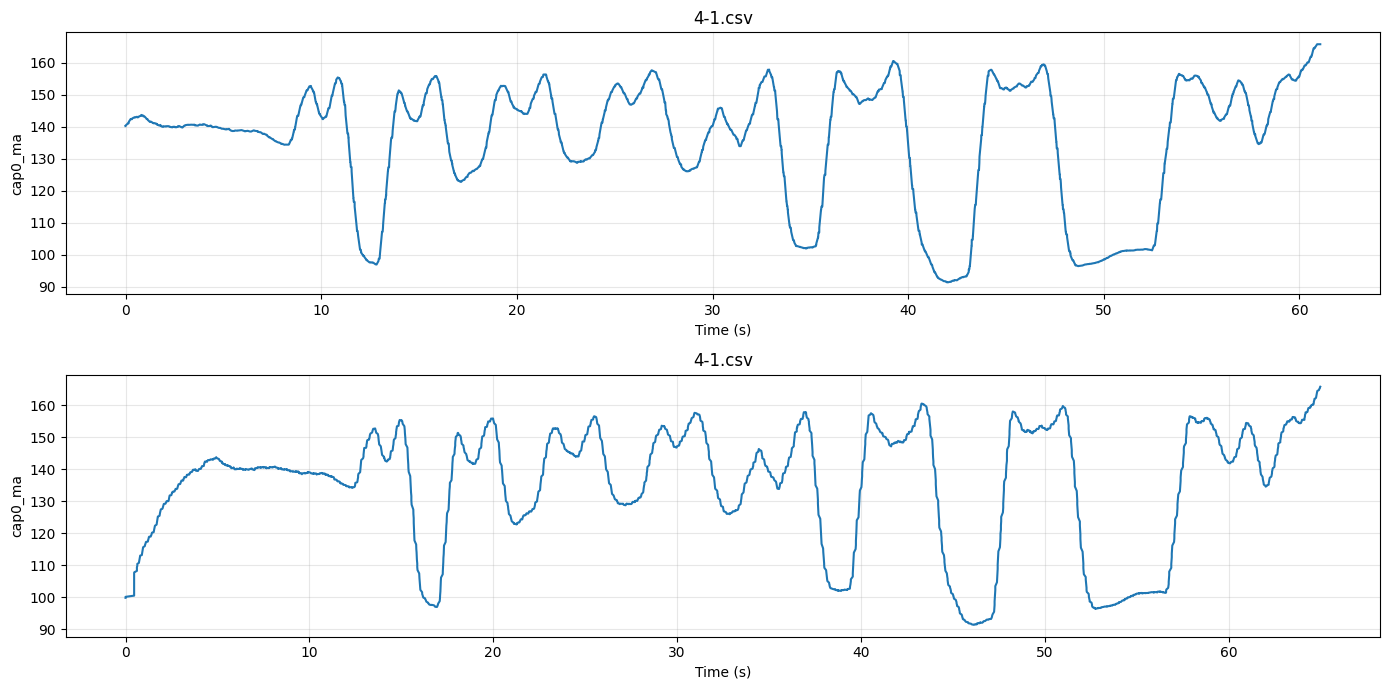

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Put your CSV files here
# =========================
file_paths = [
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/synced/4-1.csv",
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/processed_cap/4-1.csv",
    # "/path/to/file3.csv",
]

# =========================
# Settings
# =========================
USE_TIME_AXIS = True   # True = use timestamp as x-axis, False = use sample index
SMOOTH_WINDOW = None   # e.g., 20 for moving average smoothing, None = no smoothing

# =========================
# Plot cap0_ma from all files
# =========================
n_files = len(file_paths)

fig, axes = plt.subplots(
    n_files,
    1,
    figsize=(14, 3.5 * n_files),
    sharex=False
)

if n_files == 1:
    axes = [axes]

for ax, file_path in zip(axes, file_paths):
    file_path = Path(file_path)

    df = pd.read_csv(file_path)

    if "cap0_ma" not in df.columns:
        ax.set_title(f"{file_path.name} - no cap0_ma column")
        ax.axis("off")
        continue

    # Convert cap0_ma to numeric and remove empty rows
    df["cap0_ma"] = pd.to_numeric(df["cap0_ma"], errors="coerce")
    df_cap = df.dropna(subset=["cap0_ma"]).copy()

    if len(df_cap) == 0:
        ax.set_title(f"{file_path.name} - cap0_ma is empty")
        ax.axis("off")
        continue

    # Choose x-axis
    if USE_TIME_AXIS:
        time_col = None

        if "timestamp_dt" in df_cap.columns:
            time_col = "timestamp_dt"
        elif "timestamp" in df_cap.columns:
            time_col = "timestamp"

        if time_col is not None:
            df_cap[time_col] = pd.to_datetime(df_cap[time_col], errors="coerce")
            df_cap = df_cap.dropna(subset=[time_col])
            x = (df_cap[time_col] - df_cap[time_col].iloc[0]).dt.total_seconds()
            x_label = "Time (s)"
        else:
            x = range(len(df_cap))
            x_label = "Sample index"
    else:
        x = range(len(df_cap))
        x_label = "Sample index"

    y = df_cap["cap0_ma"]

    # Optional smoothing
    if SMOOTH_WINDOW is not None:
        y = y.rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).mean()

    ax.plot(x, y, linewidth=1.5)

    ax.set_title(file_path.name)
    ax.set_ylabel("cap0_ma")
    ax.set_xlabel(x_label)
    # ax.set_ylim(110,150)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

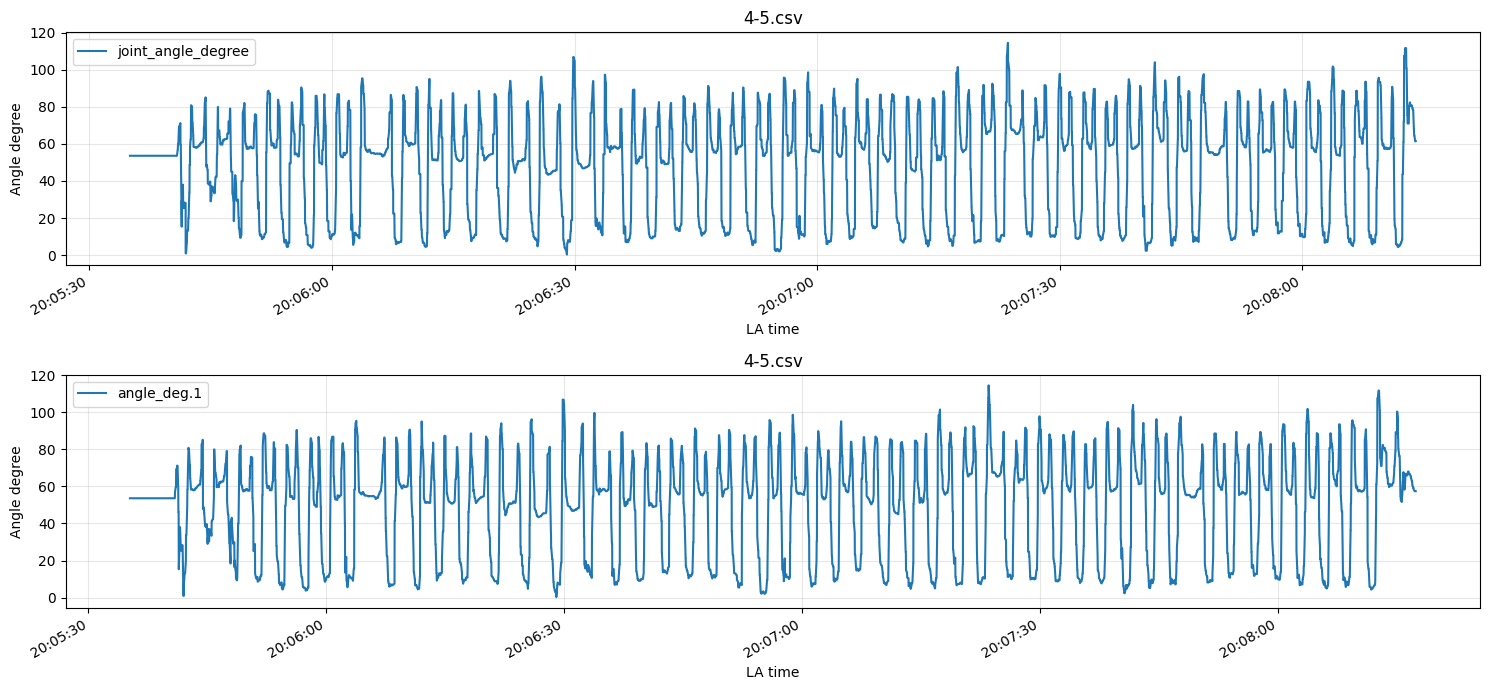

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from zoneinfo import ZoneInfo

# =========================
# Put your CSV files here
# =========================
# file_paths = [
#     "/path/to/file1.csv",
#     "/path/to/file2.csv",
#     # "/path/to/file3.csv",
# ]

# =========================
# Settings
# =========================
LA_TIMEZONE = "America/Los_Angeles"

# If your CSV timestamp is already LA local time, keep this.
# If your CSV timestamp is UTC, change this to "UTC".
INPUT_TIMEZONE = "America/Los_Angeles"

SMOOTH_WINDOW = None   # e.g., 10 or 20; None = no smoothing

TARGET_COLUMNS = [
    "joint_angle_degree",
    "jangle_degree",
    "angle_degree",
    "angle_deg",
]

# =========================
# Helper: convert timestamp to LA time
# =========================
def get_la_time(df):
    time_col = None

    if "timestamp_dt" in df.columns:
        time_col = "timestamp_dt"
    elif "timestamp" in df.columns:
        time_col = "timestamp"

    if time_col is None:
        return None, df

    t = pd.to_datetime(df[time_col], errors="coerce")
    df = df.copy()
    df["_time_raw"] = t
    df = df.dropna(subset=["_time_raw"])

    # If timestamp has no timezone, localize it first
    if df["_time_raw"].dt.tz is None:
        df["_time_la"] = (
            df["_time_raw"]
            .dt.tz_localize(INPUT_TIMEZONE)
            .dt.tz_convert(LA_TIMEZONE)
        )
    else:
        df["_time_la"] = df["_time_raw"].dt.tz_convert(LA_TIMEZONE)

    return df["_time_la"], df


# =========================
# Plot angle columns with LA time x-axis
# =========================
n_files = len(file_paths)

fig, axes = plt.subplots(
    n_files,
    1,
    figsize=(15, 3.5 * n_files),
    sharex=False
)

if n_files == 1:
    axes = [axes]

for ax, file_path in zip(axes, file_paths):
    file_path = Path(file_path)
    df = pd.read_csv(file_path)

    # Find matching angle columns, including duplicated names like angle_deg.1
    angle_cols = []
    for col in df.columns:
        base_col = col.split(".")[0]
        if base_col in TARGET_COLUMNS:
            angle_cols.append(col)

    if len(angle_cols) == 0:
        ax.set_title(f"{file_path.name} - no angle column found")
        ax.axis("off")
        continue

    x_time, df = get_la_time(df)

    if x_time is None:
        ax.set_title(f"{file_path.name} - no timestamp column found")
        ax.axis("off")
        continue

    plotted_any = False

    for col in angle_cols:
        y = pd.to_numeric(df[col], errors="coerce")

        valid = y.notna() & x_time.notna()

        if valid.sum() == 0:
            continue

        y_plot = y.copy()

        if SMOOTH_WINDOW is not None:
            y_plot = y_plot.rolling(
                window=SMOOTH_WINDOW,
                center=True,
                min_periods=1
            ).mean()

        ax.plot(
            x_time[valid],
            y_plot[valid],
            linewidth=1.5,
            label=col
        )

        plotted_any = True

    if not plotted_any:
        ax.set_title(f"{file_path.name} - angle columns are empty")
        ax.axis("off")
        continue

    ax.set_title(file_path.name)
    ax.set_ylabel("Angle degree")
    ax.set_xlabel("LA time")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Format x-axis as LA clock time
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%H:%M:%S", tz=ZoneInfo(LA_TIMEZONE))
    )
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()